In [1]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path

from ddw.utils.mrctools import load_mrc_data

C:\Users\chris\anaconda3\envs\ddw_env\lib\site-packages\lightning_utilities\core\imports.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### Functions

In [2]:
def load_volume(path):
    vol = load_mrc_data(path)
    if isinstance(vol, torch.Tensor):
        vol = vol.cpu().numpy()
    return vol.astype(np.float32)


def get_xy_slice(vol, z_idx=None):
    if z_idx is None:
        z_idx = vol.shape[0] // 2
    return vol[z_idx, :, :]


def get_xz_slice(vol, y_idx=None):
    if y_idx is None:
        y_idx = vol.shape[1] // 2
    return vol[:, y_idx, :]


def get_yz_slice(vol, x_idx=None):
    if x_idx is None:
        x_idx = vol.shape[2] // 2
    return vol[:, :, x_idx]

### Subexp01 loading data

In [3]:
print(os.getcwd())

results_dir_01 = Path("../../results/angle_sweep")
angles_01 = [30, 50, 70]

# load the paths
refined_paths_01 = {
    angle: results_dir_01 / f"tomo_even_frames+tomo_odd_frames_mw{angle}_avg_refined.rec"
    for angle in angles_01
}

for angle, path in refined_paths_01.items():
    print(angle, path.exists(), path)

    
# load the volumes
refined_avg_01 = {}

for angle, path in refined_paths_01.items():
    refined_avg_01[angle] = load_volume(path)

C:\Users\chris\Desktop\Fabio\semester-project-deepdewedge\notebooks\subexp03
30 True ..\..\results\angle_sweep\tomo_even_frames+tomo_odd_frames_mw30_avg_refined.rec
50 True ..\..\results\angle_sweep\tomo_even_frames+tomo_odd_frames_mw50_avg_refined.rec
70 True ..\..\results\angle_sweep\tomo_even_frames+tomo_odd_frames_mw70_avg_refined.rec


### Subexp02 loading data

In [4]:
results_dir_02 = Path("../../experiments/subexp02")
angles_02 = [40, 50, 60]

# load the paths
refined_paths_02 = {
    angle: results_dir_02 / f"refine_mw{angle}/tomo_even_frames+tomo_odd_frames_train{angle}_mw50_avg_refined.rec"
    for angle in angles_02
}

for angle, path in refined_paths_02.items():
    print(angle, path.exists(), path)

    
# load the volumes
refined_avg_02 = {}

for angle, path in refined_paths_02.items():
    refined_avg_02[angle] = load_volume(path)

40 True ..\..\experiments\subexp02\refine_mw40\tomo_even_frames+tomo_odd_frames_train40_mw50_avg_refined.rec
50 True ..\..\experiments\subexp02\refine_mw50\tomo_even_frames+tomo_odd_frames_train50_mw50_avg_refined.rec
60 True ..\..\experiments\subexp02\refine_mw60\tomo_even_frames+tomo_odd_frames_train60_mw50_avg_refined.rec


### Definition shared values

In [5]:
baseline_angle = 50
compare_angles_01 = [30, 70]
compare_angles_02 = [40, 60]

baseline_vol_01 = refined_avg_01[baseline_angle]
baseline_vol_02 = refined_avg_02[baseline_angle]

# slice indices
z_idx = baseline_vol_01.shape[0] // 2   # XY
y_idx = baseline_vol_01.shape[1] // 2   # XZ
x_idx = baseline_vol_01.shape[2] // 2   # YZ

# overwrite if needed
# y_idx = 640

threshold_fraction = 0.15
overlay_alpha = 0.75
overlay_cmap = "Reds"

out_dir = Path("../../figures/subexp03/comparison")
out_dir.mkdir(parents=True, exist_ok=True)

### Plotting functions

In [6]:
def robust_limits(img, p_low=1, p_high=99):
    return np.percentile(img[np.isfinite(img)], [p_low, p_high])


def get_plane_slice(vol, plane):
    if plane == "XY":
        return get_xy_slice(vol, z_idx=z_idx)
    elif plane == "XZ":
        return get_xz_slice(vol, y_idx=y_idx)
    elif plane == "YZ":
        return get_yz_slice(vol, x_idx=x_idx)
    else:
        raise ValueError("plane must be XY, XZ, or YZ")


def figsize_from_image(img, target_width=7.0, min_height=1.4, max_height=7.0):
    """
    Choose figure size from image shape.
    Keeps natural image aspect ratio.
    """
    h, w = img.shape
    aspect = h / w
    height = target_width * aspect
    height = np.clip(height, min_height, max_height)
    return (target_width, height)


def add_axis_icon(ax, plane, x0=0, y0=0, dx=0.13, dy=0.22):
    """
    Draw small orientation icon near the bottom-left border,
    with labels placed more at the outer edge like in the paper.
    """
    if plane == "XY":
        h_label, v_label = "x", "y"
    elif plane == "XZ":
        h_label, v_label = "x", "z"
    elif plane == "YZ":
        h_label, v_label = "y", "z"
    else:
        raise ValueError("plane must be XY, XZ, or YZ")

    # arrows
    ax.annotate(
        "", xy=(x0 + dx, y0), xytext=(x0, y0),
        xycoords="axes fraction",
        arrowprops=dict(arrowstyle="->", lw=2.2, color="black")
    )
    ax.annotate(
        "", xy=(x0, y0 + dy), xytext=(x0, y0),
        xycoords="axes fraction",
        arrowprops=dict(arrowstyle="->", lw=2.2, color="black")
    )

    # horizontal label: lower, closer to bottom edge
    ax.text(
        x0 + dx / 2, y0 - 0, h_label,
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=16, color="black"
    )

    # vertical label: further left, more at outer edge
    ax.text(
        x0 - 0.025, y0 + dy / 2, v_label,
        transform=ax.transAxes,
        ha="center", va="center",
        fontsize=16, color="black"
    )
    

    
def make_panel_label(exp_name, angle):
    """
    Create correct label depending on experiment.
    """
    if exp_name == "subexp01":
        # inference-time error: same trained model, different refinement angle
        return f"|refine {angle}° - refine 50°|"

    elif exp_name == "subexp02":
        # training-time error: trained at angle, all refined at 50°
        return f"|train {angle}° - train 50°|"

    else:
        return f"|condition {angle} - baseline|"

In [11]:
planes = ["XY", "XZ", "YZ"]

baseline_slices_01 = {
    plane: get_plane_slice(baseline_vol_01, plane).astype(np.float32)
    for plane in planes
}

baseline_slices_02 = {
    plane: get_plane_slice(baseline_vol_02, plane).astype(np.float32)
    for plane in planes
}


diff_slices_01 = {}
diff_slices_02 = {}

for angle in compare_angles_01:
    diff_slices_01[angle] = {}
    for plane in planes:
        cond_slice = get_plane_slice(refined_avg_01[angle], plane).astype(np.float32)
        diff_slices_01[angle][plane] = np.abs(cond_slice - baseline_slices_01[plane])



for angle in compare_angles_02:
    diff_slices_02[angle] = {}
    for plane in planes:
        cond_slice = get_plane_slice(refined_avg_02[angle], plane).astype(np.float32)
        diff_slices_02[angle][plane] = np.abs(cond_slice - baseline_slices_02[plane])


# ------------------------------------------------------------
# Step 2: shared overlay scale across all panels
# ------------------------------------------------------------

all_overlay_values_list = []

for angle in compare_angles_01:
    for plane in planes:
        all_overlay_values_list.append(diff_slices_01[angle][plane].ravel())

for angle in compare_angles_02:
    for plane in planes:
        all_overlay_values_list.append(diff_slices_02[angle][plane].ravel())

all_overlay_values = np.concatenate(all_overlay_values_list)

overlay_vmax = np.percentile(all_overlay_values, 99)
overlay_threshold = threshold_fraction * overlay_vmax

print("Global shared overlay_vmax:", overlay_vmax)
print("Global shared overlay_threshold:", overlay_threshold)



# ------------------------------------------------------------
# Step 3: save overlays with global scale
# - combined two-row panels
# - individual one-row panels for final figure assembly
# ------------------------------------------------------------


def save_overlay_panel(
    ax,
    bg,
    diff,
    plane,
    label,
    overlay_threshold,
    overlay_vmax,
    overlay_cmap="Reds",
    overlay_alpha=0.75,
):
    """
    Plot one overlay panel onto a given axis.
    """
    bg_vmin, bg_vmax = robust_limits(bg, 1, 99)

    ax.imshow(
        bg,
        cmap="gray",
        origin="lower",
        vmin=bg_vmin,
        vmax=bg_vmax,
        aspect="equal"
    )

    overlay = np.ma.masked_where(diff < overlay_threshold, diff)

    im = ax.imshow(
        overlay,
        cmap=overlay_cmap,
        origin="lower",
        vmin=overlay_threshold,
        vmax=overlay_vmax,
        alpha=overlay_alpha,
        aspect="equal"
    )

    ax.axis("off")
    add_axis_icon(ax, plane)

    ax.text(
        0.02, 0.96,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11,
        color="black",
        bbox=dict(facecolor="white", alpha=0.65, edgecolor="none", pad=2)
    )

    return im


def save_natural_aspect_overlay_panels(
    exp_name,
    baseline_slices_exp,
    diff_slices_exp,
    compare_angles_exp,
    out_dir,
    save_combined=False,
    save_individual=True,
):
    """
    Save overlay plots for one experiment using global overlay scale.

    combined:
        one PNG per plane, containing both comparison angles as rows

    individual:
        one PNG per plane and angle
    """

    for plane in planes:

        bg = baseline_slices_exp[plane]
        figsize = figsize_from_image(bg, target_width=7.0)

        # ----------------------------------------------------
        # A) Combined two-row plot
        # ----------------------------------------------------
        if save_combined:

            fig, axes = plt.subplots(
                nrows=len(compare_angles_exp),
                ncols=1,
                figsize=(figsize[0], len(compare_angles_exp) * figsize[1]),
                constrained_layout=True
            )

            if len(compare_angles_exp) == 1:
                axes = [axes]

            for row, angle in enumerate(compare_angles_exp):
                ax = axes[row]

                diff = diff_slices_exp[angle][plane]
                label = make_panel_label(exp_name, angle)

                save_overlay_panel(
                    ax=ax,
                    bg=bg,
                    diff=diff,
                    plane=plane,
                    label=label,
                    overlay_threshold=overlay_threshold,
                    overlay_vmax=overlay_vmax,
                    overlay_cmap=overlay_cmap,
                    overlay_alpha=overlay_alpha,
                )

            save_png = out_dir / f"{exp_name}_abs_overlay_{plane}_combined_globalscale.png"
            save_pdf = out_dir / f"{exp_name}_abs_overlay_{plane}_combined_globalscale.pdf"

            plt.savefig(save_png, dpi=300, bbox_inches="tight", pad_inches=0.02)
            plt.savefig(save_pdf, bbox_inches="tight", pad_inches=0.02)
            plt.show()

            print("Saved combined:", save_png)
            print("Saved combined:", save_pdf)

        # ----------------------------------------------------
        # B) Individual one-panel plots
        # ----------------------------------------------------
        if save_individual:

            for angle in compare_angles_exp:

                fig, ax = plt.subplots(
                    figsize=figsize,
                    constrained_layout=True
                )

                diff = diff_slices_exp[angle][plane]
                label = make_panel_label(exp_name, angle)

                save_overlay_panel(
                    ax=ax,
                    bg=bg,
                    diff=diff,
                    plane=plane,
                    label=label,
                    overlay_threshold=overlay_threshold,
                    overlay_vmax=overlay_vmax,
                    overlay_cmap=overlay_cmap,
                    overlay_alpha=overlay_alpha,
                )

                save_png = out_dir / f"{exp_name}_abs_overlay_{plane}_{angle}_vs_50_globalscale.png"
                save_pdf = out_dir / f"{exp_name}_abs_overlay_{plane}_{angle}_vs_50_globalscale.pdf"

                plt.savefig(save_png, dpi=300, bbox_inches="tight", pad_inches=0.02)
                plt.savefig(save_pdf, bbox_inches="tight", pad_inches=0.02)
                plt.show()

                print("Saved individual:", save_png)
                print("Saved individual:", save_pdf)

Global shared overlay_vmax: 0.2772280737757682
Global shared overlay_threshold: 0.04158421106636523


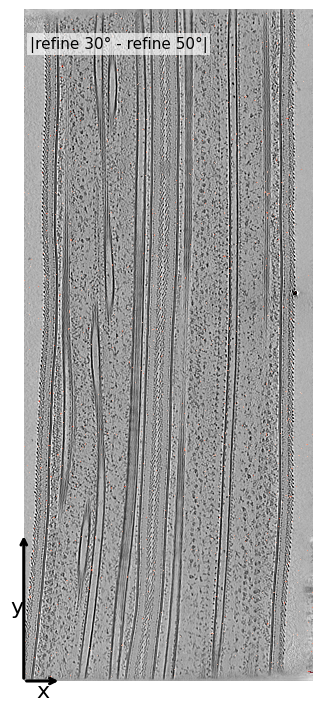

Saved individual: ..\..\figures\subexp03\comparison\subexp01_abs_overlay_XY_30_vs_50_globalscale.png
Saved individual: ..\..\figures\subexp03\comparison\subexp01_abs_overlay_XY_30_vs_50_globalscale.pdf


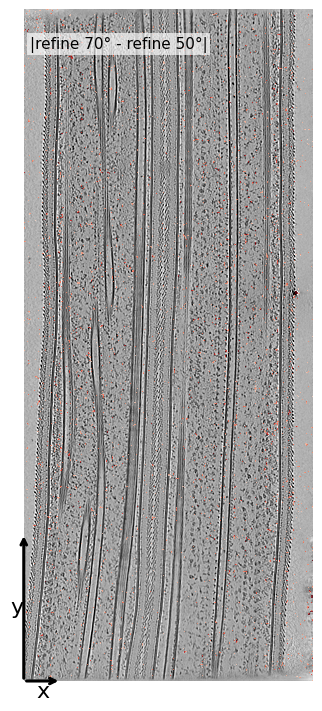

Saved individual: ..\..\figures\subexp03\comparison\subexp01_abs_overlay_XY_70_vs_50_globalscale.png
Saved individual: ..\..\figures\subexp03\comparison\subexp01_abs_overlay_XY_70_vs_50_globalscale.pdf


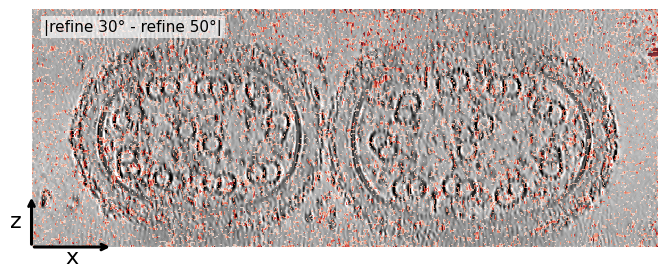

Saved individual: ..\..\figures\subexp03\comparison\subexp01_abs_overlay_XZ_30_vs_50_globalscale.png
Saved individual: ..\..\figures\subexp03\comparison\subexp01_abs_overlay_XZ_30_vs_50_globalscale.pdf


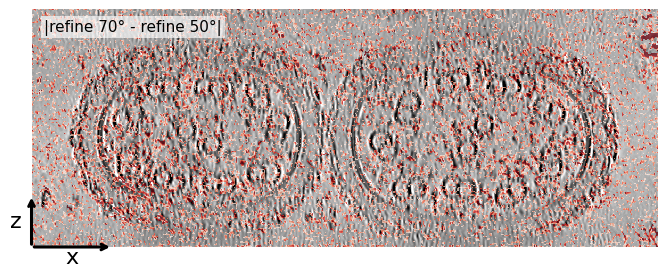

Saved individual: ..\..\figures\subexp03\comparison\subexp01_abs_overlay_XZ_70_vs_50_globalscale.png
Saved individual: ..\..\figures\subexp03\comparison\subexp01_abs_overlay_XZ_70_vs_50_globalscale.pdf


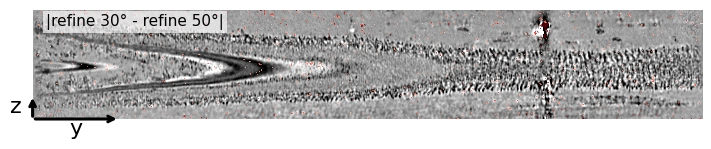

Saved individual: ..\..\figures\subexp03\comparison\subexp01_abs_overlay_YZ_30_vs_50_globalscale.png
Saved individual: ..\..\figures\subexp03\comparison\subexp01_abs_overlay_YZ_30_vs_50_globalscale.pdf


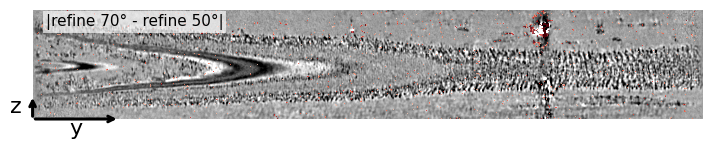

Saved individual: ..\..\figures\subexp03\comparison\subexp01_abs_overlay_YZ_70_vs_50_globalscale.png
Saved individual: ..\..\figures\subexp03\comparison\subexp01_abs_overlay_YZ_70_vs_50_globalscale.pdf


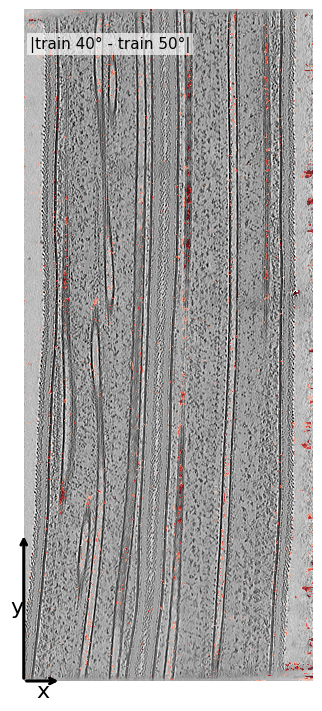

Saved individual: ..\..\figures\subexp03\comparison\subexp02_abs_overlay_XY_40_vs_50_globalscale.png
Saved individual: ..\..\figures\subexp03\comparison\subexp02_abs_overlay_XY_40_vs_50_globalscale.pdf


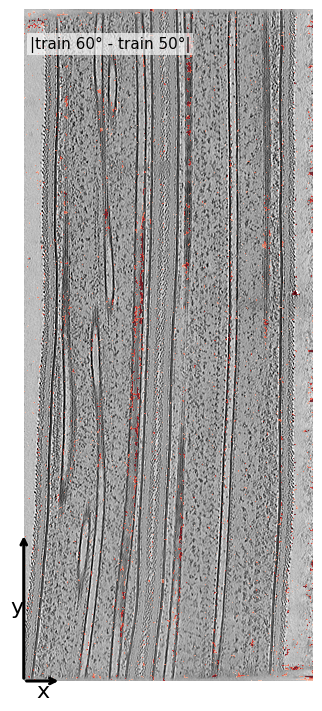

Saved individual: ..\..\figures\subexp03\comparison\subexp02_abs_overlay_XY_60_vs_50_globalscale.png
Saved individual: ..\..\figures\subexp03\comparison\subexp02_abs_overlay_XY_60_vs_50_globalscale.pdf


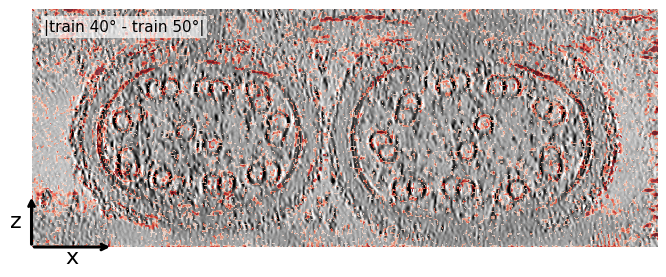

Saved individual: ..\..\figures\subexp03\comparison\subexp02_abs_overlay_XZ_40_vs_50_globalscale.png
Saved individual: ..\..\figures\subexp03\comparison\subexp02_abs_overlay_XZ_40_vs_50_globalscale.pdf


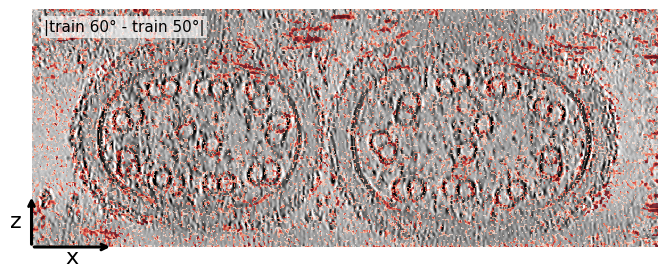

Saved individual: ..\..\figures\subexp03\comparison\subexp02_abs_overlay_XZ_60_vs_50_globalscale.png
Saved individual: ..\..\figures\subexp03\comparison\subexp02_abs_overlay_XZ_60_vs_50_globalscale.pdf


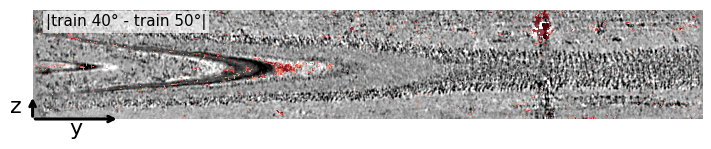

Saved individual: ..\..\figures\subexp03\comparison\subexp02_abs_overlay_YZ_40_vs_50_globalscale.png
Saved individual: ..\..\figures\subexp03\comparison\subexp02_abs_overlay_YZ_40_vs_50_globalscale.pdf


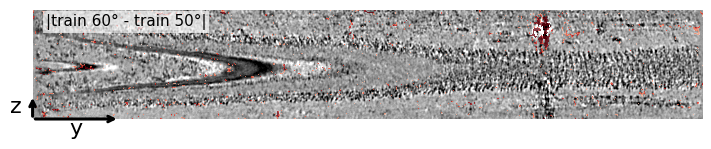

Saved individual: ..\..\figures\subexp03\comparison\subexp02_abs_overlay_YZ_60_vs_50_globalscale.png
Saved individual: ..\..\figures\subexp03\comparison\subexp02_abs_overlay_YZ_60_vs_50_globalscale.pdf


In [12]:
# ------------------------------------------------------------
# Save Subexp01
# ------------------------------------------------------------

save_natural_aspect_overlay_panels(
    exp_name="subexp01",
    baseline_slices_exp=baseline_slices_01,
    diff_slices_exp=diff_slices_01,
    compare_angles_exp=compare_angles_01,
    out_dir=out_dir,
    save_combined=False,
    save_individual=True,
)


# ------------------------------------------------------------
# Save Subexp02
# ------------------------------------------------------------

save_natural_aspect_overlay_panels(
    exp_name="subexp02",
    baseline_slices_exp=baseline_slices_02,
    diff_slices_exp=diff_slices_02,
    compare_angles_exp=compare_angles_02,
    out_dir=out_dir,
    save_combined=False,
    save_individual=True,
)